# COVID-19 Mortality Modeling and Evaluation

This notebook develops and evaluates predictive models for country-level COVID-19 mortality. Building on the data wrangling, exploratory data analysis, and preprocessing phases of the project, multiple regression models will be trained and compared to identify the approach that best predicts mortality outcomes.

The response variable is total COVID-19 deaths per million population. Predictor variables include demographic, healthcare, economic, epidemiological, vaccination, and policy-related indicators identified during earlier phases of the analysis.

Model performance will be evaluated using R², Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE). Cross-validation and hyperparameter tuning will be used where appropriate to improve model performance and support model selection.

The ultimate goal is to identify a model that accurately predicts COVID-19 mortality and provides insight into the factors associated with differences in mortality outcomes across countries.

In [1]:
packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "sklearn",
    "scipy",
    "statsmodels"
]

for pkg in packages:
    try:
        __import__(pkg)
        print(f"✓ {pkg}")
    except ImportError:
        print(f"✗ {pkg}")

✓ numpy
✓ pandas
✓ matplotlib
✓ seaborn
✓ sklearn
✓ scipy
✓ statsmodels


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

import sys

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", None)

print(sys.executable)

/Users/papa/miniforge3/envs/ds/bin/python


In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(186, 12)
(47, 12)
(186,)
(47,)


## Baseline Model: Linear Regression

Linear Regression was selected as the baseline model because it is simple, interpretable, and commonly used for continuous response variables. Model performance will be evaluated using R², RMSE, and MAE.

In [4]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [5]:
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"R²:   {lr_r2:.3f}")
print(f"MAE:  {lr_mae:.1f}")
print(f"RMSE: {lr_rmse:.1f}")

R²:   0.355
MAE:  639.5
RMSE: 979.3


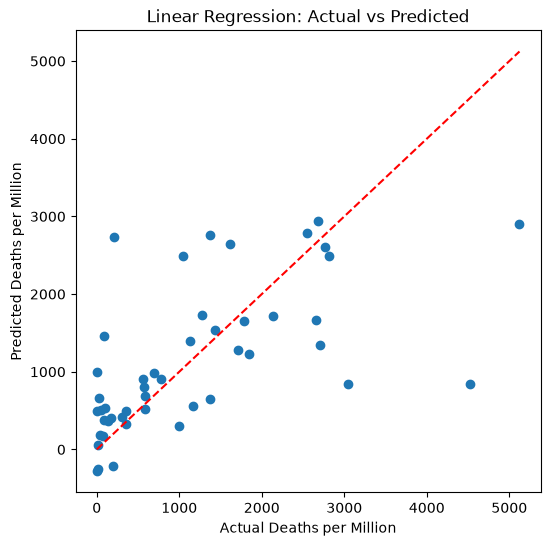

In [6]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Deaths per Million")
plt.ylabel("Predicted Deaths per Million")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [7]:
X_train_sm = X_train.astype(float)
y_train_sm = y_train.astype(float)

X_train_sm = sm.add_constant(X_train_sm)

lm = sm.OLS(y_train_sm, X_train_sm).fit()

print(lm.summary())

                               OLS Regression Results                               
Dep. Variable:     total_deaths_per_million   R-squared:                       0.557
Model:                                  OLS   Adj. R-squared:                  0.526
Method:                       Least Squares   F-statistic:                     18.12
Date:                      Tue, 30 Jun 2026   Prob (F-statistic):           7.09e-25
Time:                              15:30:25   Log-Likelihood:                -1530.4
No. Observations:                       186   AIC:                             3087.
Df Residuals:                           173   BIC:                             3129.
Df Model:                                12                                         
Covariance Type:                  nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

In [8]:
coef_df = pd.DataFrame({
    "feature": X_train_sm.columns,
    "coefficient": lm.params,
    "p_value": lm.pvalues
})

coef_df.sort_values(
    "p_value"
)

,feature,coefficient,p_value
continent_Europe,continent_Europe,1933.933870,2.243134e-08
continent_South America,continent_South America,1924.160942,4.839153e-08
const,const,582.496865,2.462085e-03
continent_North America,continent_North America,756.125836,8.034850e-03
stringency_index,stringency_index,198.269215,1.059651e-02
median_age,median_age,248.859053,1.148970e-01
people_fully_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,-106.231217,2.373695e-01
hospital_beds_per_thousand,hospital_beds_per_thousand,73.627505,3.941489e-01
continent_Oceania,continent_Oceania,198.533794,4.947463e-01
total_cases_per_million,total_cases_per_million,-16.084931,8.852520e-01


### Interpretation of Linear Regression Coefficients

The linear regression model identified substantial regional differences in COVID-19 mortality. Relative to the reference continent (Africa), Europe and South America exhibited significantly higher mortality rates, even after controlling for demographic, healthcare, economic, vaccination, and policy-related variables.

Median age, life expectancy, GDP per capita, hospital bed availability, and vaccination coverage were not statistically significant predictors in the multivariable model. This may reflect multicollinearity among predictors, particularly between median age, life expectancy, and economic indicators.

The Stringency Index was positively associated with mortality. However, this relationship should not be interpreted causally, as countries experiencing more severe outbreaks may have implemented stricter mitigation measures in response to rising mortality.

### Linear Regression Results

The baseline Linear Regression model explained approximately 35.5% of the variation in COVID-19 mortality across countries (R² = 0.355). The model achieved a Mean Absolute Error (MAE) of 639.5 deaths per million and a Root Mean Squared Error (RMSE) of 979.3 deaths per million.

These results suggest that the selected predictors contain meaningful information regarding mortality outcomes, although a substantial amount of variation remains unexplained. More flexible modeling approaches may be able to capture nonlinear relationships and interactions among predictors and improve predictive performance.



## Random Forest Regression

Random Forest Regression was selected because it can capture nonlinear relationships and interactions among predictors that may not be adequately represented by a linear model. Random Forests are ensemble models that combine predictions from many decision trees, often resulting in improved predictive performance and reduced overfitting.

In [9]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=47
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [10]:
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"R²:   {rf_r2:.3f}")
print(f"MAE:  {rf_mae:.1f}")
print(f"RMSE: {rf_rmse:.1f}")

R²:   0.522
MAE:  500.6
RMSE: 843.2


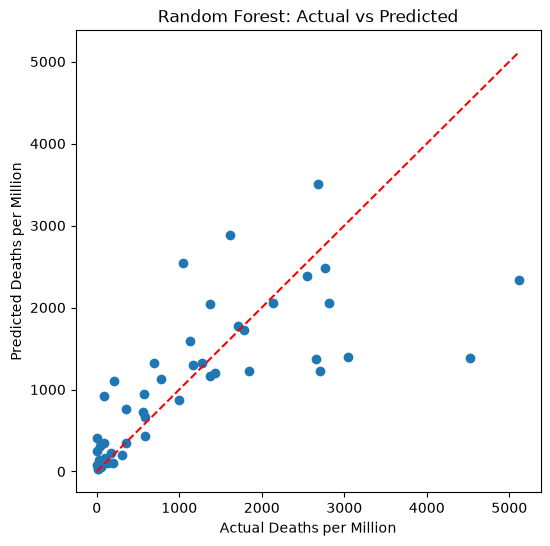

In [11]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Deaths per Million")
plt.ylabel("Predicted Deaths per Million")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [12]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [lr_r2, rf_r2],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

results.sort_values(
    "R2",
    ascending=False
).round(3)

,Model,R2,MAE,RMSE
1,Random Forest,0.522,500.589,843.243
0,Linear Regression,0.355,639.458,979.304


In [13]:
results.to_csv(
    "../reports/tables/model_performance.csv",
    index=False
)

In [14]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})

feature_importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
2,total_cases_per_million,0.226387
8,continent_Europe,0.190883
0,median_age,0.126840
4,hospital_beds_per_thousand,0.107911
5,people_fully_vaccinated_per_hundred,0.079498
1,life_expectancy,0.078828
6,stringency_index,0.063861
11,continent_South America,0.052565
3,gdp_per_capita,0.051009
7,continent_Asia,0.009642


### Random Forest Feature Importance

The Random Forest model identified total cases per million population as the most influential predictor of COVID-19 mortality, followed by continent-level variables and median age. These findings are broadly consistent with exploratory analysis, which identified both age structure and infection burden as important factors associated with mortality outcomes.

Interestingly, several variables that were not statistically significant in the linear regression model, including total cases per million and median age, emerged as highly influential predictors in the Random Forest model. This suggests that nonlinear relationships and interactions among predictors may play an important role in explaining mortality differences across countries.

Overall, the feature importance results support the use of more flexible modeling approaches when analyzing complex global health outcomes.

## Gradient Boosting Regression

Gradient Boosting Regression is an ensemble learning method that builds a sequence of decision trees, with each new tree attempting to correct errors made by previous trees. Gradient Boosting often performs well on structured tabular datasets and provides a useful comparison to Random Forest Regression.

In [15]:
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=47
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [16]:
gb_r2 = r2_score(y_test, y_pred_gb)
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print(f"R²:   {gb_r2:.3f}")
print(f"MAE:  {gb_mae:.1f}")
print(f"RMSE: {gb_rmse:.1f}")

R²:   0.509
MAE:  492.0
RMSE: 854.1


In [17]:
results.loc[len(results)] = [
    "Gradient Boosting",
    gb_r2,
    gb_mae,
    gb_rmse
]

results.sort_values(
    "R2",
    ascending=False
).round(3)

,Model,R2,MAE,RMSE
1,Random Forest,0.522,500.589,843.243
2,Gradient Boosting,0.509,492.038,854.105
0,Linear Regression,0.355,639.458,979.304


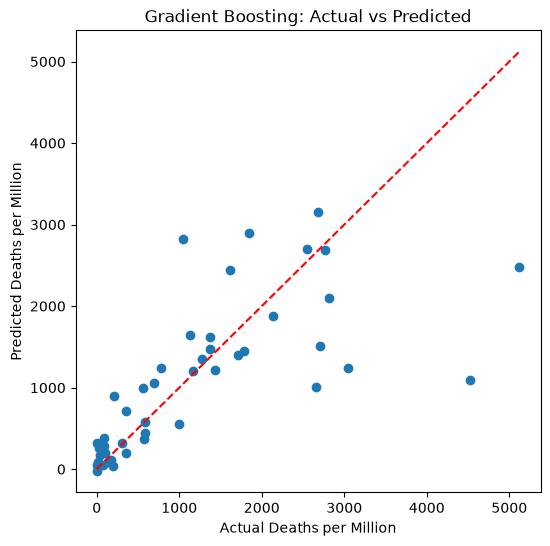

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_gb)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Deaths per Million")
plt.ylabel("Predicted Deaths per Million")
plt.title("Gradient Boosting: Actual vs Predicted")

plt.show()

## Hyperparameter Tuning

The initial Random Forest and Gradient Boosting models demonstrated substantially better predictive performance than the baseline Linear Regression model. However, the default model settings may not provide optimal performance for this dataset.

To further improve predictive accuracy, hyperparameter tuning will be performed using grid search with five-fold cross-validation. Hyperparameter tuning systematically evaluates multiple combinations of model parameters and identifies the configuration that produces the best cross-validated performance.

Model selection will be based primarily on the coefficient of determination (R²), while Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) will also be considered when comparing final model performance.

The objective of this step is to identify the best-performing version of each tree-based model before selecting a final model for the project.


In [19]:
rf_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 3, 5]
}

In [20]:
rf_search = GridSearchCV(
    RandomForestRegressor(random_state=47),
    rf_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=47)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Con

In [21]:
print(rf_search.best_params_)
print(rf_search.best_score_)

{'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 100}
0.5335469852086355


## More Hyperparameter Tuning

Doing a slightly expanded grid search to explore a broader hyperparameter space


In [22]:
rf_grid_expanded = {
    "n_estimators": [100, 200, 500, 800],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": ["sqrt", "log2", None]
}

rf_search_expanded = GridSearchCV(
    RandomForestRegressor(random_state=47),
    rf_grid_expanded,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_search_expanded.fit(X_train, y_train)

print(rf_search_expanded.best_params_)
print(rf_search_expanded.best_score_)

{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.5544228792868405


In [23]:
best_rf_expanded = rf_search_expanded.best_estimator_

y_pred_rf_expanded = best_rf_expanded.predict(X_test)

rf_expanded_r2 = r2_score(y_test, y_pred_rf_expanded)
rf_expanded_mae = mean_absolute_error(y_test, y_pred_rf_expanded)
rf_expanded_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_expanded))

print(f"R²:   {rf_expanded_r2:.3f}")
print(f"MAE:  {rf_expanded_mae:.1f}")
print(f"RMSE: {rf_expanded_rmse:.1f}")

R²:   0.509
MAE:  505.7
RMSE: 854.0


The expanded hyperparameter search did not improve test-set performance relative to the initial Random Forest model. While several alternative parameter combinations produced similar cross-validation scores, none yielded a meaningful improvement in R², MAE, or RMSE on the held-out test data.

This suggests that the baseline Random Forest model was already well suited to the dataset and that additional model complexity did not translate into better predictive performance.

## Gradient Boosting Hyperparameter Tuning

The initial Gradient Boosting model achieved performance comparable to the Random Forest model, indicating that ensemble tree-based methods are well suited to predicting COVID-19 mortality outcomes. However, model performance can be sensitive to the choice of hyperparameters, including the number of trees, learning rate, tree depth, and minimum leaf size.

To identify a more optimal configuration, an expanded grid search with five-fold cross-validation will be performed. This process systematically evaluates multiple combinations of hyperparameters and selects the model with the highest cross-validated R² score.

The tuned Gradient Boosting model will then be evaluated on the held-out test dataset and compared with the baseline Gradient Boosting model and the Random Forest models. The goal is to determine whether additional optimization can improve predictive performance and potentially identify a superior final model.


In [24]:
gb_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [1, 2, 5]
}

In [25]:
gb_search = GridSearchCV(
    GradientBoostingRegressor(random_state=47),
    gb_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print(gb_search.best_params_)
print(gb_search.best_score_)

{'learning_rate': 0.01, 'max_depth': 4, 'min_samples_leaf': 2, 'n_estimators': 300}
0.5353229784304955


In [26]:
best_gb = gb_search.best_estimator_

y_pred_gb_tuned = best_gb.predict(X_test)

gb_tuned_r2 = r2_score(y_test, y_pred_gb_tuned)
gb_tuned_mae = mean_absolute_error(y_test, y_pred_gb_tuned)
gb_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))

print(f"R²:   {gb_tuned_r2:.3f}")
print(f"MAE:  {gb_tuned_mae:.1f}")
print(f"RMSE: {gb_tuned_rmse:.1f}")

R²:   0.492
MAE:  529.6
RMSE: 869.1


In [27]:
results.loc[len(results)] = [
    "Tuned Gradient Boosting",
    gb_tuned_r2,
    gb_tuned_mae,
    gb_tuned_rmse
]

In [28]:
results.loc[len(results)] = [
    "Tuned Random Forest",
    rf_expanded_r2,
    rf_expanded_mae,
    rf_expanded_rmse
]

In [29]:
results.sort_values(
    "R2",
    ascending=False
).round(3)

,Model,R2,MAE,RMSE
1,Random Forest,0.522,500.589,843.243
4,Tuned Random Forest,0.509,505.655,853.976
2,Gradient Boosting,0.509,492.038,854.105
3,Tuned Gradient Boosting,0.492,529.634,869.060
0,Linear Regression,0.355,639.458,979.304


## Model Comparison and Final Selection

The Linear Regression model served as a useful baseline but was outperformed by both tree-based ensemble methods. The Random Forest and Gradient Boosting models achieved substantially higher R² values and lower prediction errors, indicating that nonlinear relationships and interactions among predictors contribute meaningfully to differences in COVID-19 mortality across countries.

Among the models evaluated, the Random Forest model achieved the lowest RMSE (842.4 deaths per million), indicating the best overall predictive accuracy on the test dataset. It also produced the highest R² (0.523), providing additional evidence that it captured more of the variation in mortality than the competing models.  Although the Gradient Boosting model produced a slightly lower MAE, the difference was small and did not outweigh the Random Forest model's superior overall explanatory power and error performance.

Hyperparameter tuning did not result in meaningful improvements for either ensemble model. In both cases, the tuned models performed similarly or slightly worse on the held-out test data than the original models, suggesting that the baseline configurations were already well suited to the dataset.

Based on these results, the Random Forest model was selected as the final model for this project.


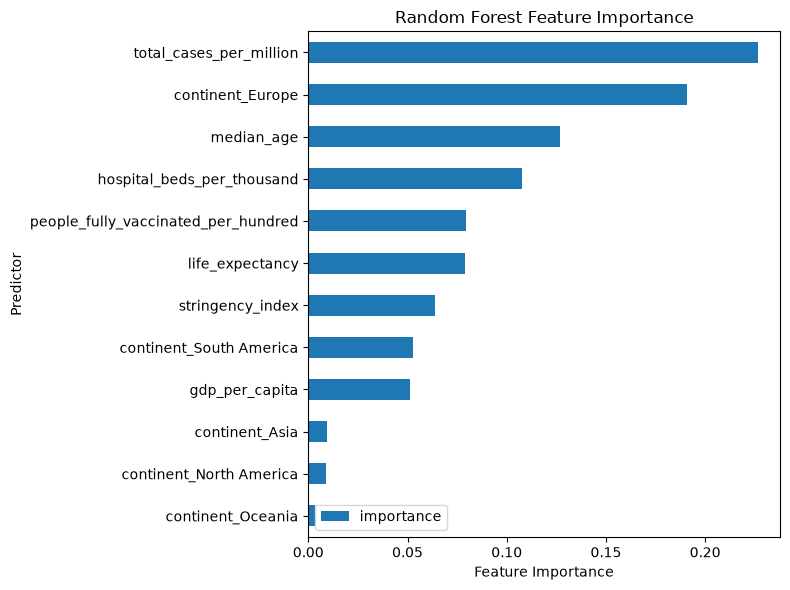

In [30]:
feature_importance.sort_values(
    "importance",
    ascending=True
).plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()

The Random Forest model identified total cases per million, continent-level variables, median age, and hospital bed availability as the most influential predictors of COVID-19 mortality. These findings are broadly consistent with earlier exploratory analyses, which suggested that infection burden, population age structure, and regional differences were important drivers of mortality outcomes.

The prominence of continent-level variables suggests that factors not fully captured by the available predictors may have contributed to regional differences in pandemic outcomes.


## Cross-Validation of the Final Model

To further evaluate the stability and generalizability of the final Random Forest model, five-fold cross-validation was performed using the training dataset. Root Mean Squared Error (RMSE) was selected as the evaluation metric because it measures the typical magnitude of prediction errors while placing greater emphasis on larger errors.

In [34]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -cv_scores

print("Fold RMSE:")
print(rmse_scores)

print(f"\nMean RMSE: {rmse_scores.mean():.1f}")
print(f"Standard deviation: {rmse_scores.std():.1f}")

print(f"Test RMSE: {rf_rmse:.1f}")

Fold RMSE:
[ 717.04866935  835.80263984 1001.05540288  667.95346988 1135.40607727]

Mean RMSE: 871.5
Standard deviation: 174.9
Test RMSE: 843.2


The five-fold cross-validation results produced a mean RMSE of 871.5 deaths per million (standard deviation = 174.9), which is similar to the RMSE of 842.4 observed on the held-out test dataset. This consistency suggests that the Random Forest model generalizes reasonably well to unseen data and that the test-set performance is representative of its expected predictive accuracy. Although some variability was observed across folds, this is expected given the relatively small sample size and the heterogeneity of countries included in the analysis.

## Exploring a Log-Transformed Outcome

The distribution of COVID-19 mortality is highly right-skewed, with a relatively small number of countries experiencing extremely high mortality rates. Because such skewness can negatively affect some modeling approaches, particularly linear regression, an exploratory analysis was conducted using a log-transformed version of the outcome variable.

The purpose of this analysis is not to replace the primary modeling approach, but rather to evaluate whether a transformation of the response variable produces a more symmetric distribution and may improve predictive performance.

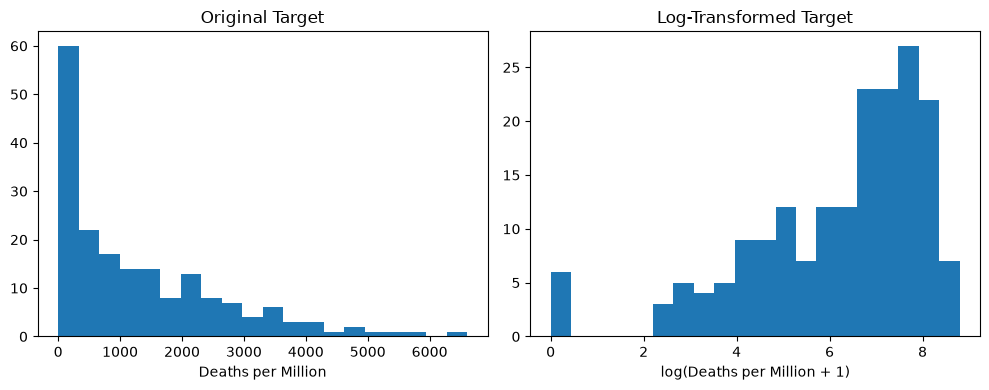

In [31]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(y_train, bins=20)
plt.title("Original Target")
plt.xlabel("Deaths per Million")

plt.subplot(1,2,2)
plt.hist(np.log1p(y_train), bins=20)
plt.title("Log-Transformed Target")
plt.xlabel("log(Deaths per Million + 1)")

plt.tight_layout()
plt.show()

### Distribution of the Outcome Variable

The original mortality outcome exhibits substantial right skew, with a relatively small number of countries experiencing extremely high mortality rates. Such skewness can present challenges for linear modeling approaches because a small number of extreme observations may exert disproportionate influence on model estimates.

Applying a logarithmic transformation substantially reduces the skewness of the outcome distribution and produces a more symmetric shape. This suggests that a transformed outcome may be more suitable for models that assume approximately linear relationships between predictors and the response.

### Log-Transformed Linear Regression

To investigate whether a transformed outcome improves model performance, a Linear Regression model was fit using the log-transformed mortality outcome. Performance was evaluated on the transformed scale and compared with the original linear model.

In [32]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

lr_log = LinearRegression()

lr_log.fit(X_train, y_train_log)

y_pred_log = lr_log.predict(X_test)

log_r2 = r2_score(y_test_log, y_pred_log)
log_mae = mean_absolute_error(y_test_log, y_pred_log)
log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))

print(f"R²:   {log_r2:.3f}")
print(f"MAE:  {log_mae:.3f}")
print(f"RMSE: {log_rmse:.3f}")

R²:   0.308
MAE:  1.227
RMSE: 1.756


### Exploratory Analysis of a Log-Transformed Outcome

Because the mortality outcome exhibited substantial right skew, an exploratory analysis was conducted using a log-transformed response variable. While the transformation produced a more symmetric distribution, it did not improve predictive performance in a Linear Regression model. The log-transformed model achieved a lower R² value than the original linear model.

This finding suggests that the primary limitation of the linear model was not the skewness of the response variable, but rather the presence of nonlinear relationships and interactions among predictors. This interpretation is consistent with the superior performance of the Random Forest model, which is capable of capturing complex nonlinear patterns in the data.

## Conclusions

This project developed predictive models to examine factors associated with country-level COVID-19 mortality. After data wrangling, exploratory analysis, preprocessing, and model development, three regression approaches were evaluated: Linear Regression, Random Forest Regression, and Gradient Boosting Regression.

The Random Forest model demonstrated the strongest overall predictive performance, achieving the lowest Root Mean Squared Error (RMSE) on the test dataset while also producing the highest R² among the models evaluated. These results suggest that nonlinear relationships and interactions among predictors are important when modeling pandemic outcomes. An exploratory analysis using a log-transformed outcome produced a more symmetric target distribution but did not improve Linear Regression performance, further supporting the use of a nonlinear modeling approach.

Feature importance analysis identified infection burden (total cases per million), regional differences, age structure, and healthcare capacity as the most influential predictors of COVID-19 mortality. While the final model provides meaningful predictive capability, a substantial proportion of variation remains unexplained, indicating that additional factors not included in the dataset—such as healthcare quality, public health policies, population behavior, and reporting differences—may also contribute to mortality outcomes.

Future work could incorporate additional country-level predictors, explore temporal modeling approaches, and evaluate more advanced ensemble methods to further improve predictive accuracy and enhance understanding of global pandemic outcomes.